In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :24, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

In [ ]:
n_components = 50
max_iter = 500
tol = 1e-8
verbose = False

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

ELBO =  26945977.877, change =  5.23e-06, time taken =  21.5:  31%|███       | 154/500 [1:03:01<2:21:35, 24.55s/it]  


KeyboardInterrupt: 

# Mask with last mode completely masked

Change is small enough, early break:  33%|███▎      | 167/500 [05:51<11:40,  2.10s/it]                              

Number of negative deltas: 1
When do they occur? [167]
what is their magnitude? [-6.480019879591154e-09]
List of elbos: [-2745562619.827566, 84795515.23291527, 164485426.08536264, 198040334.4682094, 201874984.31733298, 202185577.3589704, 202208450.66717032, 202215014.1716234, 202218442.9121841, 202220221.22139618, 202221649.95860833, 202222952.3139004, 202224063.90432537, 202224921.535163, 202225775.50470155, 202226665.66942236, 202227414.59525666, 202228053.02028263, 202228742.92371675, 202229539.7071328, 202230384.12163308, 202231000.0719788, 202231643.57792997, 202232263.36092457, 202232820.02828276, 202233357.0733383, 202233957.08691323, 202234470.9178189, 202234667.41706324, 202234872.36209288, 202235106.73114094, 202235356.5753466, 202235631.34202862, 202235965.78696707, 202236334.63225868, 202236523.42871812, 202236675.23882753, 202236834.61810285, 202236989.94698933, 202237144.10827842, 202237294.97838098, 202237445.6422251, 202237596.51070175, 202237751.1849766, 202237910.2931

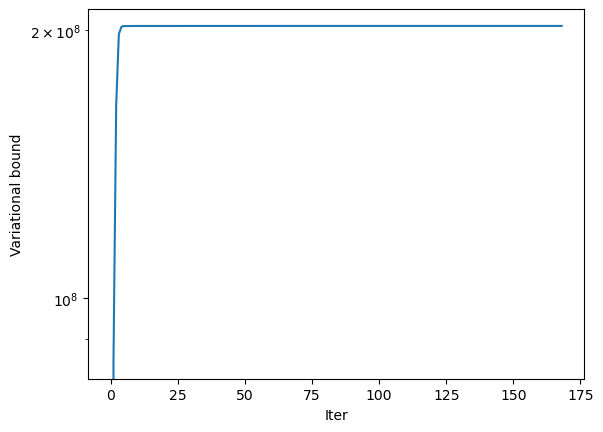

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [ ]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with the 1st and 3rd indices masked

ELBO = 202270259.23518994, change =  2.58e-08, time taken =  2.09: 100%|██████████| 500/500 [17:24<00:00,  2.09s/it]

Number of negative deltas: 2
When do they occur? [223, 224]
what is their magnitude? [-5.2195106499320965e-08, -1.7665009546406974e-08]
List of elbos: [-2732203912.2541943, 84053141.06398574, 167422678.99123833, 198973074.66770175, 202005984.9683561, 202209845.6105322, 202229576.3175656, 202236613.89110324, 202240118.20955193, 202242550.89910644, 202244585.01802465, 202246159.0370271, 202247486.87922925, 202248704.07377967, 202249793.82750693, 202250599.67378363, 202251280.8491065, 202251907.6942401, 202252330.46160254, 202252724.38877556, 202253116.07211363, 202253506.88256016, 202253905.81735176, 202254310.8385441, 202254621.61830574, 202254875.122768, 202255108.2509059, 202255319.85229778, 202255522.0583178, 202255715.91045678, 202255905.1771764, 202256087.31879807, 202256263.86921725, 202256436.24911407, 202256602.59563485, 202256763.58985004, 202256922.46529996, 202257080.11524132, 202257236.25893158, 202257389.8784341, 202257544.6251078, 202257702.58358812, 202257864.08476153, 20

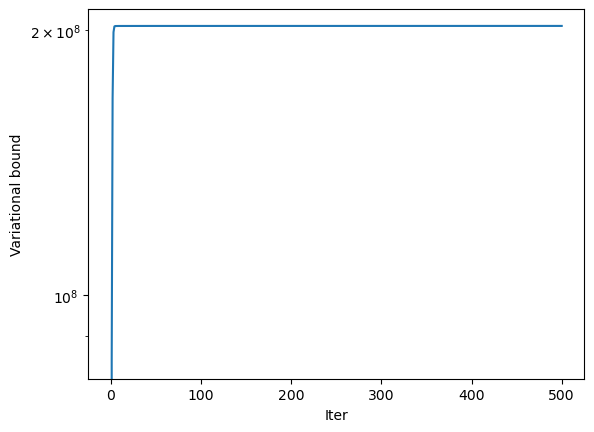

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [ ]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

In [ ]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

ELBO = 203144923.06582332, change =  6.73e-05, time taken =  2.79:   1%|▏         | 7/500 [00:20<24:21,  2.97s/it]


KeyboardInterrupt: 

# No mask

ELBO = 203770153.73026472, change =  4.16e-09, time taken =  2.01: 100%|██████████| 500/500 [16:48<00:00,  2.02s/it]

Number of negative deltas: 24
When do they occur? [258, 259, 260, 261, 262, 263, 264, 265, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405]
what is their magnitude? [-1.3509587973251096e-08, -3.224714755364091e-08, -3.200075417251333e-08, -1.9619597305372633e-08, -1.606166327830471e-08, -1.610086756754078e-08, -8.70335694563938e-09, -2.425613549997905e-09, -1.1021252458949941e-10, -1.1808093798306079e-08, -2.3501222951219046e-08, -3.2927798766576375e-08, -3.600410028336591e-08, -3.4799561980924514e-08, -3.0815335397578206e-08, -2.5545834860567775e-08, -2.0036410127160374e-08, -1.4734916762310625e-08, -1.0278500047998793e-08, -8.725792652077433e-09, -6.683708726737085e-09, -4.474245637428185e-09, -2.551838911760319e-09, -7.258651904007737e-10]
List of elbos: [-2923408304.282899, 86808323.37737538, 173790254.91673553, 201602572.37200654, 203612675.64188763, 203714752.91015244, 203729291.10123128, 203734586.00292277, 203737890.31048387, 203740340.48997328, 2

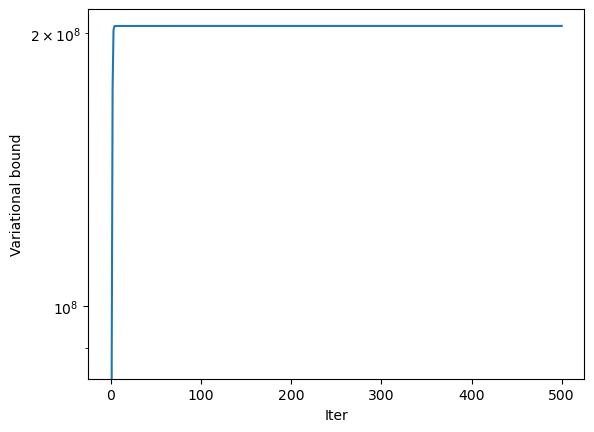

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [ ]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)

In [ ]:
with torch.no_grad():
    # torch.cuda.synchronize()
    b1 = BPTF_model._elbo(data, mask)
    torch.cuda.synchronize()
    b2 = BPTF_model._elbo(data, mask)
print((b2 - b1) * 1e8)               # absolute change in “ULPs”

tensor(0., device='cuda:0')
